In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [3]:
Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")
Main.include("anomalous dim\\cusp\\cusp.jl")
Main.include("anomalous dim\\non-cusp\\gammaH.jl")
Main.include("anomalous dim\\non-cusp\\gammaB.jl")
Main.include("anomalous dim\\non-cusp\\gammaS.jl")
Main.include("anomalous dim\\non-cusp\\gammav.jl")
Main.include("hard\\hard.jl")
Main.include("jet\\jet.jl")
Main.include("soft\\soft.jl")
Main.include("sigma.jl")
Main.include("error.jl")
Main.include("fixed order\\perturbation.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")

<PyCall.jlwrap non_singular_sigma_χ>

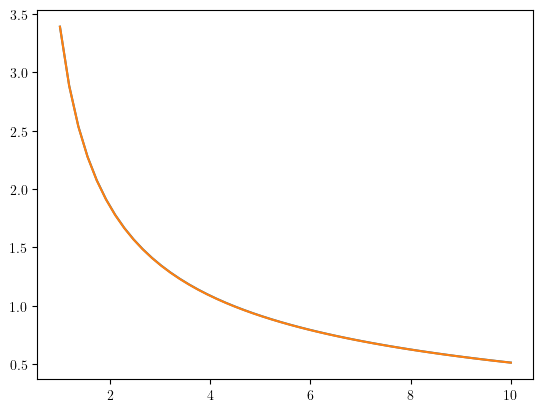

In [51]:
xlist = np.linspace(1.0,10.0)  # This creates a range from 1 to 10 inclusive

y1list = []  # It's good practice to specify the type for performance reasons
y2list = []

for x in xlist:
    αs = Main.alpha_s_func(μf=x, μi=91.2, αs=0.118, order=4, nf=5)
    y1 = Main.γH_analytic(Q=91.2, αs_μ=αs, αs_ini=0.118, μ_ini=91.2, order=3, nf=5)
    y2 = Main.γH_final(Q=91.2, μ=x, αs_ini=0.118, μ_ini=91.2, order=3, nf=5)
    y1list.append(y1)
    y2list.append(y2)    

plt.plot(xlist, y1list, label="γH Analytic")
plt.plot(xlist, y2list, label="γH Final")  # Use plot! to add to the existing plot

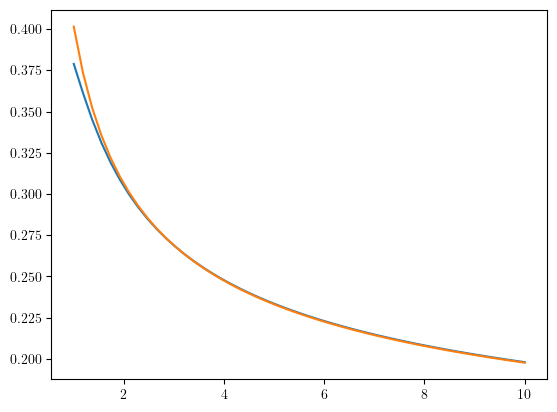

In [50]:
xlist = np.linspace(1.0,10.0)  # This creates a range from 1 to 10 inclusive

y1list = []  # It's good practice to specify the type for performance reasons
y2list = []

for x in xlist:
    αs = Main.alpha_s_func(μf=x, μi=91.2, αs=0.118, order=4, nf=5)
    y1 = Main.γS_analytic(ν=x/2, αs_μ=αs, αs_ini=0.118, μ_ini=91.2, order=3, nf=5)
    y2 = Main.γS_final(ν=x/2, μ=x, αs_ini=0.118, μ_ini=91.2, order=3, nf=5)
    y1list.append(y1)
    y2list.append(y2)    

plt.plot(xlist, y1list, label="γS Analytic")
plt.plot(xlist, y2list, label="γS Final")  # Use plot! to add to the existing plot

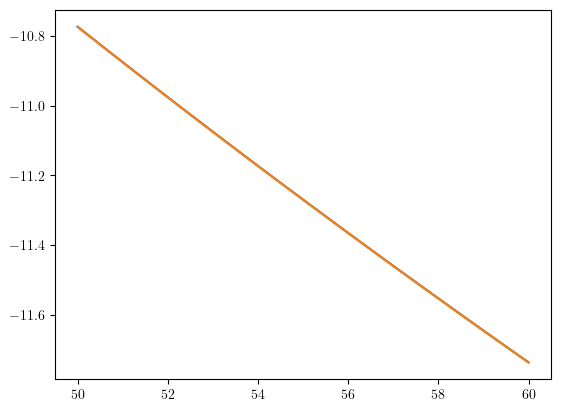

In [49]:
xlist = np.linspace(50.0,60.0)  # This creates a range from 1 to 10 inclusive

y1list = []  # It's good practice to specify the type for performance reasons
y2list = []

for x in xlist:
    y1 = Main.γν_analytic(b=x, μB=10.0, αs_ini=0.118, μ_ini=91.2, order=3, nf=5,bmax=1.1)
    y2 = Main.γν_final(b=x, μB=10.0, αs_ini=0.118, μ_ini=91.2, order=3, nf=5,bmax=1.1)
    y1list.append(y1)
    y2list.append(y2)    

plt.plot(xlist, y1list, label="γS Analytic")
plt.plot(xlist, y2list, label="γS Final")  # Use plot! to add to the existing plot

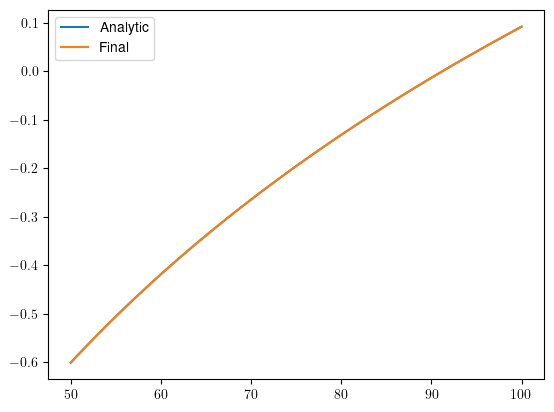

In [48]:
xlist = np.linspace(50.0,100.0)  # This creates a range from 1 to 10 inclusive

y1list = []  # It's good practice to specify the type for performance reasons
y2list = []

for x in xlist:
    αs = Main.alpha_s_func(μf=x, μi=91.2, αs=0.118, order=4, nf=5)    
    y1 = Main.log_αs(αs_μi=0.118, αs_μf=αs, order=4, nf=5)
    y2 = np.log(x/91.2)
    y1list.append(y1)
    y2list.append(y2)    

plt.plot(xlist, y1list, label="Analytic")
plt.plot(xlist, y2list, label="Final")  # Use plot! to add to the existing plot
plt.legend()
plt.show()